In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("../data/bodyfat.csv")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [2]:
# data.hist(bins = 20 , figsize=(15,10))

In [3]:
data['Weight'] = data['Weight'] * 0.453593

data['Height'] = data['Height']  * 2.54


In [4]:
def label_gender(row):
    # First, we check the overall physical traits like BodyFat and Density.
    if row['BodyFat'] > 24 or row['Density'] < 1.06:
        # If body fat is high or density is low, it's more likely female.
        return 'Female'
    else:
        # Now we need to consider additional factors to distinguish male
        if row['Weight'] > 80 or row['Height'] > 175:
            return 'Male'  # Higher weight or height may suggest male
        
        # Further checking specific measurements that typically differ between genders
        if row['Chest'] > 100 or row['Abdomen'] > 90:
            return 'Male'  # Larger chest or abdomen measurements suggest male
        if row['Hip'] > 100 or row['Thigh'] > 60:
            return 'Male'  # Larger hips or thighs may indicate male
        if row['Neck'] > 37:
            return 'Male'  # Larger neck circumference more typical for males
        
    # If none of the above conditions are met, it's more likely to be female
    return 'Female'

# Apply the function to each row in the dataset
data['Gender'] = data.apply(label_gender, axis=1)

data.head()


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Gender
0,1.0708,12.3,23,69.966720,172.085,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,Female
1,1.0853,6.1,22,78.584987,183.515,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,Male
2,1.0414,25.3,22,69.853322,168.275,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,Female
3,1.0751,10.4,26,83.801307,183.515,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,Male
4,1.0340,28.7,24,83.574510,180.975,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,Female


In [5]:
# Exclude non-numeric columns
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Calculate correlation only on numeric columns
corr_matrix = numeric_data.corr()
corr_matrix

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
Density,1.000000,-0.987782,-0.277637,-0.594062,0.097881,-0.472966,-0.682599,-0.798955,-0.609331,-0.553091,-0.495040,-0.264890,-0.487109,-0.351648,-0.325716
BodyFat,-0.987782,1.000000,0.291458,0.612414,-0.089495,0.490592,0.702620,0.813432,0.625201,0.559608,0.508665,0.265970,0.493271,0.361387,0.346575
Age,-0.277637,0.291458,1.000000,-0.012746,-0.171645,0.113505,0.176450,0.230409,-0.050332,-0.200096,0.017516,-0.105058,-0.041162,-0.085056,0.213531
Weight,-0.594062,0.612414,-0.012746,1.000000,0.308279,0.830716,0.894191,0.887995,0.940884,0.868694,0.853167,0.613685,0.800416,0.630301,0.729775
Height,0.097881,-0.089495,-0.171645,0.308279,1.000000,0.253710,0.134892,0.087813,0.170394,0.148436,0.286053,0.264744,0.207816,0.228649,0.322065
Neck,-0.472966,0.490592,0.113505,0.830716,0.253710,1.000000,0.784835,0.754077,0.734958,0.695697,0.672405,0.477892,0.731146,0.623660,0.744826
Chest,-0.682599,0.702620,0.176450,0.894191,0.134892,0.784835,1.000000,0.915828,0.829420,0.729859,0.719496,0.482988,0.727907,0.580173,0.660162
Abdomen,-0.798955,0.813432,0.230409,0.887995,0.087813,0.754077,0.915828,1.000000,0.874066,0.766624,0.737179,0.453223,0.684983,0.503316,0.619832
Hip,-0.609331,0.625201,-0.050332,0.940884,0.170394,0.734958,0.829420,0.874066,1.000000,0.896410,0.823473,0.558387,0.739273,0.545014,0.630090
Thigh,-0.553091,0.559608,-0.200096,0.868694,0.148436,0.695697,0.729859,0.766624,0.896410,1.000000,0.799170,0.539797,0.761477,0.566842,0.558685


In [6]:
def infer_risk(row):
    # Gender specific adjustments
    gender = row['Gender']
    
    # Heart Disease Risk (example of gender-based adjustment)
    if gender == 'Male' and row['BodyFat'] > 30 or row['Age'] > 50:
        heart_risk = 'High'
    elif gender == 'Male' and (row['BodyFat'] > 25 or row['Age'] > 40):
        heart_risk = 'Medium'
    elif gender == 'Female' and row['BodyFat'] > 30 or row['Age'] > 55:
        heart_risk = 'High'
    elif gender == 'Female' and (row['BodyFat'] > 25 or row['Age'] > 45):
        heart_risk = 'Medium'
    else:
        heart_risk = 'Low'
    
    # Diabetes Risk (example of gender-based adjustment)
    if gender == 'Male' and (row['BodyFat'] > 30 or row['Age'] > 45 or row['Weight'] > 85):
        diabetes_risk = 'High'
    elif gender == 'Female' and (row['BodyFat'] > 30 or row['Age'] > 50 or row['Weight'] > 80):
        diabetes_risk = 'High'
    elif gender == 'Male' and (row['BodyFat'] > 25 or row['Age'] > 40):
        diabetes_risk = 'Medium'
    elif gender == 'Female' and (row['BodyFat'] > 25 or row['Age'] > 45):
        diabetes_risk = 'Medium'
    else:
        diabetes_risk = 'Low'
    
    # Osteoporosis Risk (example of gender-based adjustment)
    if gender == 'Female' and row['Density'] < 1.0:
        osteoporosis_risk = 'High'
    elif gender == 'Female' and row['Density'] < 1.1:
        osteoporosis_risk = 'Medium'
    elif gender == 'Male' and row['Density'] < 0.9:
        osteoporosis_risk = 'High'
    else:
        osteoporosis_risk = 'Low'
    
    # Prioritize diseases based on high-risk classification
    if heart_risk == 'High':
        disease = 'Heart Disease - High Risk'
    elif diabetes_risk == 'High':
        disease = 'Diabetes - High Risk'
    elif osteoporosis_risk == 'High':
        disease = 'Osteoporosis - High Risk'
    elif heart_risk == 'Medium':
        disease = 'Heart Disease - Not High Risk'
    elif diabetes_risk == 'Medium':
        disease = 'Diabetes - Not High Risk'
    elif osteoporosis_risk == 'Medium':
        disease = 'Osteoporosis - Not High Risk'
    else:
        disease = 'No Significant Risk'
    
    return disease

# Apply the function to classify the disease and risk
data['Disease'] = data.apply(infer_risk, axis=1)

# Display the updated dataset
data.head()


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Gender,Disease
0,1.0708,12.3,23,69.966720,172.085,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,Female,Osteoporosis - Not High Risk
1,1.0853,6.1,22,78.584987,183.515,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,Male,No Significant Risk
2,1.0414,25.3,22,69.853322,168.275,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,Female,Heart Disease - Not High Risk
3,1.0751,10.4,26,83.801307,183.515,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,Male,No Significant Risk
4,1.0340,28.7,24,83.574510,180.975,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,Female,Diabetes - High Risk


In [7]:
from sklearn.model_selection import train_test_split
train_data , test_data = train_test_split(data , test_size= 0.2 , random_state=42)
print(f"train_data {train_data.shape}")
print(f"test_data {test_data.shape}")
train_data.head()

train_data (201, 17)
test_data (51, 17)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Gender,Disease
136,1.0491,21.8,39,75.636633,179.705,37.0,92.9,86.1,95.6,58.8,36.1,22.4,32.7,28.3,17.1,Female,Osteoporosis - Not High Risk
55,1.0473,22.6,54,89.811414,182.880,39.9,107.6,100.0,99.6,57.2,38.0,22.0,35.9,30.2,18.9,Female,Heart Disease - High Risk
204,1.0209,34.8,44,101.151239,177.165,40.9,121.6,113.9,107.1,63.5,40.3,21.8,34.8,30.7,17.4,Female,Heart Disease - High Risk
216,1.0678,13.6,51,67.698755,177.165,34.8,92.8,81.1,96.3,53.8,36.5,21.5,31.3,26.3,17.8,Male,Heart Disease - High Risk
147,1.0322,29.6,25,93.666955,177.165,40.9,110.9,100.5,106.2,68.4,40.8,24.6,33.3,29.7,18.4,Female,Diabetes - High Risk


In [8]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder for Disease column
disease_encoder = LabelEncoder()
train_data['Disease'] = disease_encoder.fit_transform(train_data['Disease'])

# Label Encoder for Gender column
gender_encoder = LabelEncoder()
train_data['Gender'] = gender_encoder.fit_transform(train_data['Gender'])

# Display the updated dataset
train_data.head()


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Gender,Disease
136,1.0491,21.8,39,75.636633,179.705,37.0,92.9,86.1,95.6,58.8,36.1,22.4,32.7,28.3,17.1,0,4
55,1.0473,22.6,54,89.811414,182.880,39.9,107.6,100.0,99.6,57.2,38.0,22.0,35.9,30.2,18.9,0,1
204,1.0209,34.8,44,101.151239,177.165,40.9,121.6,113.9,107.1,63.5,40.3,21.8,34.8,30.7,17.4,0,1
216,1.0678,13.6,51,67.698755,177.165,34.8,92.8,81.1,96.3,53.8,36.5,21.5,31.3,26.3,17.8,1,1
147,1.0322,29.6,25,93.666955,177.165,40.9,110.9,100.5,106.2,68.4,40.8,24.6,33.3,29.7,18.4,0,0


In [9]:
# Label Encoder for Disease column on test set
test_data['Disease'] = disease_encoder.transform(test_data['Disease'])

# Label Encoder for Gender column on test set
test_data['Gender'] = gender_encoder.transform(test_data['Gender'])



In [10]:
from sklearn.preprocessing import StandardScaler

# List of columns to exclude from scaling (categorical columns)
exclude_columns = ['Gender', 'Disease']  # Only 'Gender' and 'Disease' columns need to be excluded

# Separate continuous columns from the dataset
continuous_columns = [col for col in train_data.columns if col not in exclude_columns]

# Initialize the scaler
scaler = StandardScaler()

# Apply scaling only to continuous columns in the training set
train_data[continuous_columns] = scaler.fit_transform(train_data[continuous_columns])

# Apply the same scaling transformation to the test set using the fitted scaler
test_data[continuous_columns] = scaler.transform(test_data[continuous_columns])

# Display the updated train and test data (optional)
print(train_data.head())
print(test_data.head())


      Density   BodyFat       Age    Weight    Height      Neck     Chest  \
136 -0.297964  0.272532 -0.517891 -0.405512  0.180513 -0.410457 -0.913066   
55  -0.389045  0.364753  0.664124  0.713217  0.499346  0.827925  0.819871   
204 -1.724897  1.771116 -0.123886  1.608201 -0.074553  1.254953  2.470288   
216  0.648265 -0.672728  0.427721 -1.032001 -0.074553 -1.349919 -0.924855   
147 -1.153112  1.171683 -1.621106  1.017512 -0.074553  1.254953  1.208898   

      Abdomen       Hip     Thigh      Knee     Ankle    Biceps   Forearm  \
136 -0.613129 -0.613767 -0.083661 -1.030530 -0.380167  0.211451 -0.187997   
55   0.692826 -0.027908 -0.396150 -0.235461 -0.634879  1.298621  0.748065   
204  1.998780  1.070576  0.834275  0.726992 -0.762235  0.924906  0.994397   
216 -1.082897 -0.511242 -1.060189 -0.863147 -0.953269 -0.264186 -1.173325   
147  0.739802  0.938758  1.791273  0.936221  1.020749  0.415295  0.501733   

        Wrist  Gender  Disease  
136 -1.220435       0        4  
55   0.7

In [11]:
X_train = train_data.drop(columns=['Disease'])  # Features
y_train = train_data['Disease']  # Target label

X_test = test_data.drop(columns=['Disease'])  # Features for the test set
y_test = test_data['Disease']  # Target label for the test set


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
# Initialize the classifier
model = DecisionTreeClassifier(random_state=42)

# Perform cross-validation
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

# Print the mean accuracy
print(f'Decision Tree cross-validation accuracy: {scores.mean()}')


Decision Tree cross-validation accuracy: 0.9106097560975611


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Train the model on the full training data
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Print classification report and confusion matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         3
           3       1.00      0.70      0.82        10
           4       1.00      1.00      1.00         6

    accuracy                           0.94        51
   macro avg       0.97      0.94      0.95        51
weighted avg       0.95      0.94      0.94        51



In [14]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Print best parameters and the best score
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best cross-validation accuracy: {grid_search.best_score_}')


Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validation accuracy: 0.9353658536585365


In [15]:
# Get feature importance
importances = model.feature_importances_

# Display feature importance
for feature, importance in zip(X_train.columns, importances):
    print(f'{feature}: {importance:.4f}')


Density: 0.1512
BodyFat: 0.0000
Age: 0.5144
Weight: 0.1817
Height: 0.0159
Neck: 0.0000
Chest: 0.0000
Abdomen: 0.0068
Hip: 0.0222
Thigh: 0.0000
Knee: 0.0000
Ankle: 0.0000
Biceps: 0.0000
Forearm: 0.0045
Wrist: 0.0000
Gender: 0.1033


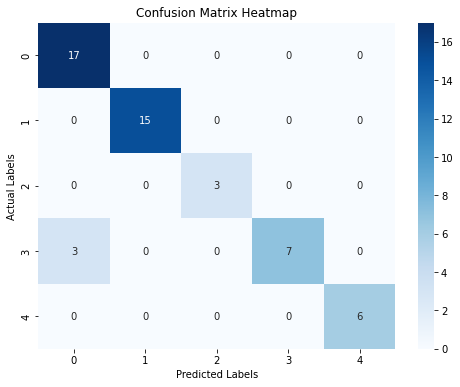

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [19]:
import pandas as pd

# New input data with completely different values
new_data = {
    'Density': [1.05, 1.25, 1.35, 1.0, 1.1],  # Different values for Density
    'BodyFat': [35.5, 22.8, 18.3, 40.2, 12.7],  # Different values for BodyFat
    'Age': [50, 25, 60, 32, 45],  # Different values for Age
    'Weight': [95, 65, 85, 120, 55],  # Different values for Weight
    'Height': [170, 160, 180, 155, 165],  # Different values for Height
    'Neck': [42, 34, 45, 38, 36],  # Different values for Neck
    'Chest': [110, 92, 105, 95, 85],  # Different values for Chest
    'Abdomen': [110, 80, 95, 120, 75],  # Different values for Abdomen
    'Hip': [102, 88, 105, 110, 95],  # Different values for Hip
    'Thigh': [75, 55, 60, 80, 50],  # Different values for Thigh
    'Knee': [50, 40, 42, 45, 37],  # Different values for Knee
    'Ankle': [24, 20, 23, 25, 18],  # Different values for Ankle
    'Biceps': [45, 32, 36, 48, 28],  # Different values for Biceps
    'Forearm': [35, 28, 33, 38, 30],  # Different values for Forearm
    'Wrist': [20, 17, 18, 22, 16],  # Different values for Wrist
    'Gender': [0, 0, 0, 0, 0]  # Different values for Gender (0: Male, 1: Female)
}

# Convert the new data into a DataFrame
new_data_df = pd.DataFrame(new_data)

# Ensure the data is scaled (same scaling as applied during training)
new_data_df[continuous_columns] = scaler.transform(new_data_df[continuous_columns])

# Use the model to predict
prediction = model.predict(new_data_df)

# Decode the predicted label to the original string value
predicted_disease = disease_encoder.inverse_transform(prediction)

# Print the predicted disease in string form
print(f"Predicted Disease Class: {predicted_disease}")


Predicted Disease Class: ['Diabetes - High Risk' 'Osteoporosis - Not High Risk'
 'Heart Disease - High Risk' 'Heart Disease - High Risk'
 'Osteoporosis - Not High Risk']


In [18]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'decision_tree_model.joblib')

# Save the encoder (for Disease column)
joblib.dump(disease_encoder, 'disease_encoder.joblib')

# Save the scaler
joblib.dump(scaler, 'scaler.joblib')


['scaler.joblib']